# Change Properties of the target

Once you have loaded a target and potentially fine tuned the detector or spectrograph setup, you may have to see the effect of changing (simular) targets. 

This is simple using `set_properties()` which enables you to change any properties of the target

## Type Ia Supernovae

Let's load a redshift=1.0 SN Ia with a c=0.3 and and x1=0.2, setup the instrument to reach a signal to noise of 20.

In [1]:
import slicersim
import numpy as np

In [30]:
lazuli_snia = slicersim.LazuliSupernova(redshift=1.0, c=0.3, x1=0.2)
_ = lazuli_snia.setup_to_snr(20, per_resolution=False, 
                             lbda_range=[6000, 7000], 
                             frame="rest")

### check that this worked.

In [32]:
# get the snr spectrum
lbda, flux, variance = lazuli_snia.get_spectrum()
snr_spec = flux/np.sqrt(variance)

redshift = lazuli_snia.get_properties("redshift")
flag_in = (lbda>6000*(1+redshift)) & (lbda<7000*(1+redshift))
np.mean(snr_spec[flag_in]) # slightly smaller

np.float64(19.772363522248696)

=> 19.77 vs. 20: close enough

### now let's change the target and recompute the SNR

The target values are what was expected when triggering the target.

Yet, in reality, the target properties differ. The actual redshift is 1.05, the c=0.2 and x1=-2

In [34]:
# Say these are the true target parameters, slight different than the expected ones
lazuli_snia.change_properties(redshift=1.05, c=0.2, x1=-2.)

In [35]:
lbda, flux, variance = lazuli_snia.get_spectrum()
snr_spec = flux/np.sqrt(variance)

let's now see the resulting signal to noise ratio

In [36]:
redshift = 1.05
flag_in = (lbda>6000*(1+redshift)) & (lbda<7000*(1+redshift))
np.mean(snr_spec[flag_in]) # slightly smaller

np.float64(16.512089859546517)

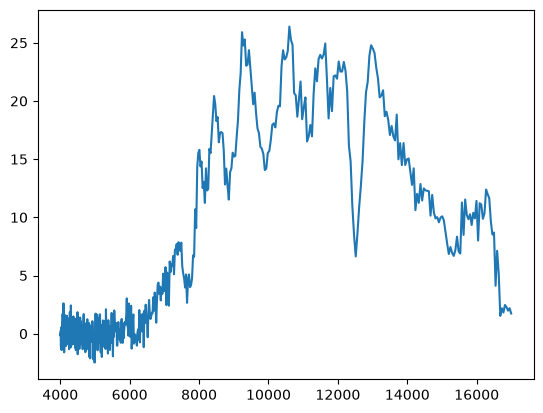

In [37]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots()
ax.plot(lbda, snr_spec)

# Any Spectrum or CalSpec

For generic target (loaded given their spectral flux) the some things you can change is the observed magnitude in a given band. 

This band has to be a [sncosmo band](https://sncosmo.readthedocs.io/en/stable/bandpass-list.html)

In [38]:
lazuli_star = slicersim.LazuliCalSpec("gd71")

In [40]:
lazuli_star.change_properties(mag=22, band="lssti")

In [41]:
lazuli_star.change_properties(mag=22, band="lssti")
lbda, flux_22, variance_22 = lazuli_star.get_spectrum(unit="flambda", incl_error=False)

lazuli_star.change_properties(mag=21, band="lssti")
lbda, flux_21, variance_21 = lazuli_star.get_spectrum(unit="flambda", incl_error=False)

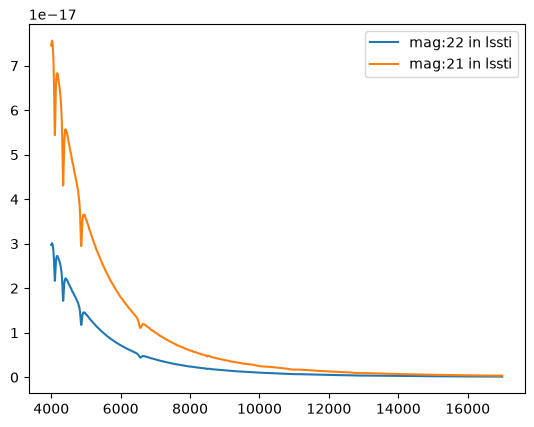

In [42]:
fig, ax = plt.subplots()
ax.plot(lbda, flux_22, label="mag:22 in lssti")
ax.plot(lbda, flux_21, label="mag:21 in lssti")
ax.legend()